In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
# Visualization style
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("TravelInsurancePrediction.csv")

In [3]:
df.head()

,Unnamed: 0,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,0,31,Government Sector,Yes,400000,6,1,No,No,0
1,1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0
2,2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1
3,3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0
4,4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0


In [4]:
df.tail()

,Unnamed: 0,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
1982,1982,33,Private Sector/Self Employed,Yes,1500000,4,0,Yes,Yes,1
1983,1983,28,Private Sector/Self Employed,Yes,1750000,5,1,No,Yes,0
1984,1984,28,Private Sector/Self Employed,Yes,1150000,6,1,No,No,0
1985,1985,34,Private Sector/Self Employed,Yes,1000000,6,0,Yes,Yes,1
1986,1986,34,Private Sector/Self Employed,Yes,500000,4,0,No,No,0


In [5]:
df.shape

(1987, 10)

In [6]:
df.columns

Index(['Unnamed: 0', 'Age', 'Employment Type', 'GraduateOrNot', 'AnnualIncome',
       'FamilyMembers', 'ChronicDiseases', 'FrequentFlyer',
       'EverTravelledAbroad', 'TravelInsurance'],
      dtype='object')

In [7]:
df.dtypes

Unnamed: 0              int64
Age                     int64
Employment Type        object
GraduateOrNot          object
AnnualIncome            int64
FamilyMembers           int64
ChronicDiseases         int64
FrequentFlyer          object
EverTravelledAbroad    object
TravelInsurance         int64
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1987 entries, 0 to 1986
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Unnamed: 0           1987 non-null   int64 
 1   Age                  1987 non-null   int64 
 2   Employment Type      1987 non-null   object
 3   GraduateOrNot        1987 non-null   object
 4   AnnualIncome         1987 non-null   int64 
 5   FamilyMembers        1987 non-null   int64 
 6   ChronicDiseases      1987 non-null   int64 
 7   FrequentFlyer        1987 non-null   object
 8   EverTravelledAbroad  1987 non-null   object
 9   TravelInsurance      1987 non-null   int64 
dtypes: int64(6), object(4)
memory usage: 155.4+ KB


In [9]:
df.describe()

,Unnamed: 0,Age,AnnualIncome,FamilyMembers,ChronicDiseases,TravelInsurance
count,1987.000000,1987.000000,1.987000e+03,1987.000000,1987.000000,1987.000000
mean,993.000000,29.650226,9.327630e+05,4.752894,0.277806,0.357323
std,573.741812,2.913308,3.768557e+05,1.609650,0.448030,0.479332
min,0.000000,25.000000,3.000000e+05,2.000000,0.000000,0.000000
25%,496.500000,28.000000,6.000000e+05,4.000000,0.000000,0.000000
50%,993.000000,29.000000,9.000000e+05,5.000000,0.000000,0.000000
75%,1489.500000,32.000000,1.250000e+06,6.000000,1.000000,1.000000
max,1986.000000,35.000000,1.800000e+06,9.000000,1.000000,1.000000


In [10]:
df.isnull().sum()

Unnamed: 0             0
Age                    0
Employment Type        0
GraduateOrNot          0
AnnualIncome           0
FamilyMembers          0
ChronicDiseases        0
FrequentFlyer          0
EverTravelledAbroad    0
TravelInsurance        0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["Employment Type"].unique()

array(['Government Sector', 'Private Sector/Self Employed'], dtype=object)

In [13]:
df["GraduateOrNot"].unique()

array(['Yes', 'No'], dtype=object)

In [14]:
df["FrequentFlyer"].unique()

array(['No', 'Yes'], dtype=object)

In [15]:
df["EverTravelledAbroad"].unique()

array(['No', 'Yes'], dtype=object)

In [16]:
df["TravelInsurance"].value_counts()

TravelInsurance
0    1277
1     710
Name: count, dtype: int64

In [17]:
df["TravelInsurance"].value_counts(normalize=True) * 100

TravelInsurance
0    64.26774
1    35.73226
Name: proportion, dtype: float64

In [18]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [19]:
df.shape

(1987, 9)

In [21]:
df.duplicated().sum()

np.int64(738)

In [22]:
df = df.drop_duplicates()

In [23]:
df.shape

(1249, 9)

In [25]:
print("Dataset Shape:", df.shape)
print("Missing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (1249, 9)
Missing Values:
Age                    0
Employment Type        0
GraduateOrNot          0
AnnualIncome           0
FamilyMembers          0
ChronicDiseases        0
FrequentFlyer          0
EverTravelledAbroad    0
TravelInsurance        0
dtype: int64

Duplicate Rows: 0


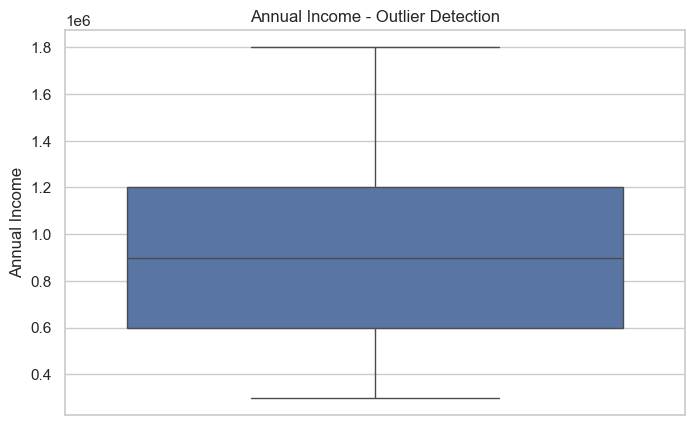

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(y=df["AnnualIncome"])

plt.title("Annual Income - Outlier Detection")
plt.ylabel("Annual Income")

plt.show()

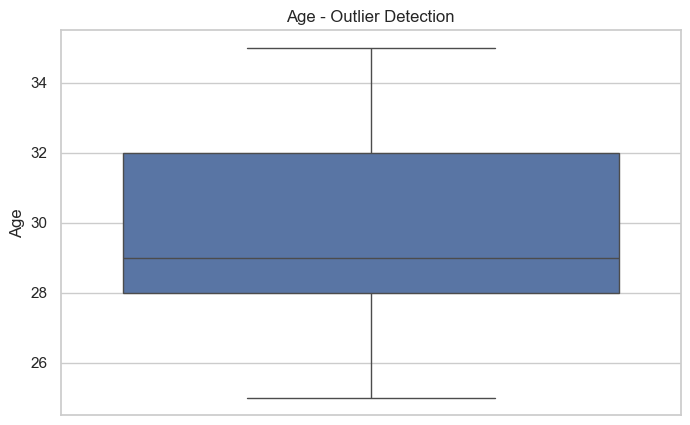

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(y=df["Age"])

plt.title("Age - Outlier Detection")
plt.ylabel("Age")

plt.show()

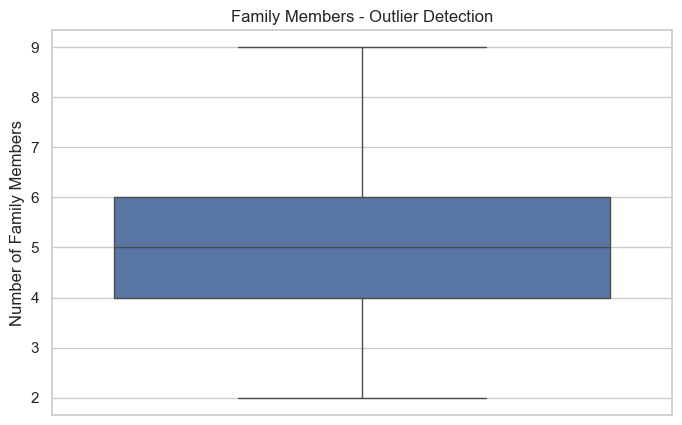

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(y=df["FamilyMembers"])

plt.title("Family Members - Outlier Detection")
plt.ylabel("Number of Family Members")

plt.show()

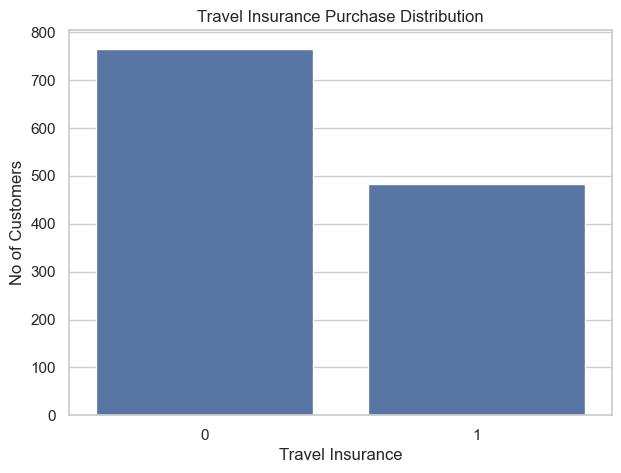

In [30]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="TravelInsurance")

plt.title("Travel Insurance Purchase Distribution")
plt.xlabel("Travel Insurance")
plt.ylabel("No of Customers")

plt.show()

In [32]:
df["TravelInsurance"].value_counts(normalize=True)*100

TravelInsurance
0    61.329063
1    38.670937
Name: proportion, dtype: float64

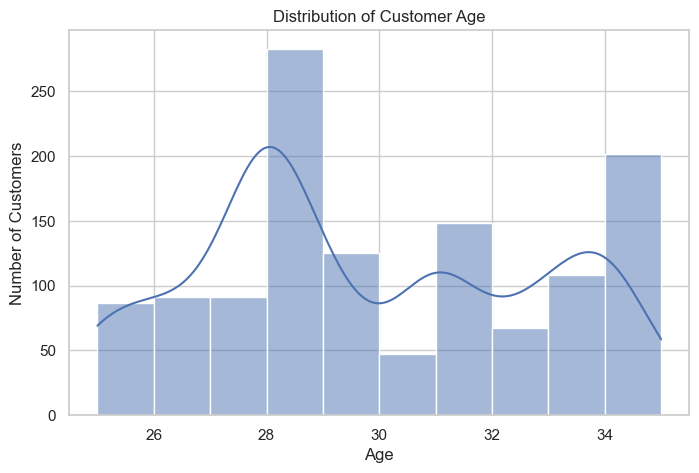

In [33]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Age", bins=10, kde=True)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

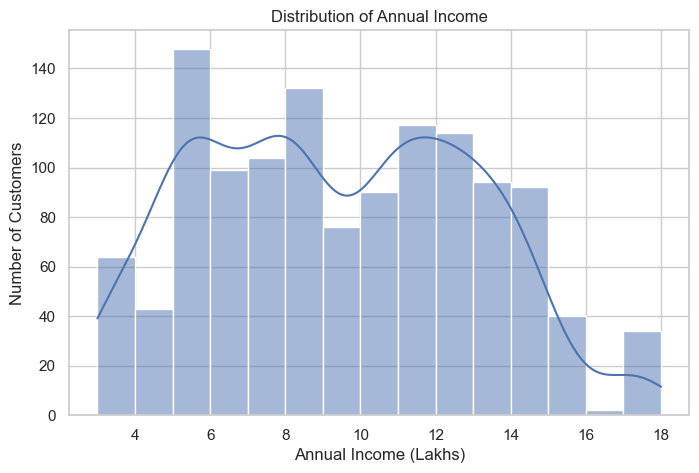

In [34]:
plt.figure(figsize=(8, 5))

sns.histplot(
    x=df["AnnualIncome"] / 100000,
    bins=15,
    kde=True
)

plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income (Lakhs)")
plt.ylabel("Number of Customers")

plt.show()

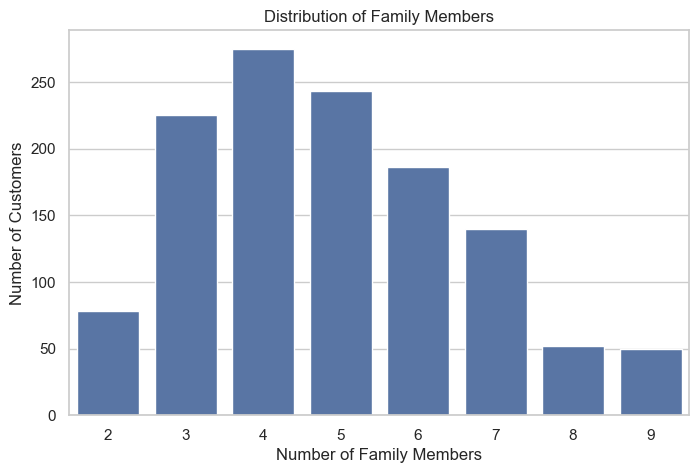

In [35]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="FamilyMembers"
)

plt.title("Distribution of Family Members")
plt.xlabel("Number of Family Members")
plt.ylabel("Number of Customers")

plt.show()

In [36]:
df["FamilyMembers"].value_counts().sort_index()

FamilyMembers
2     78
3    225
4    275
5    243
6    186
7    140
8     52
9     50
Name: count, dtype: int64

In [37]:
df["FamilyMembers"].mean()

np.float64(4.89031224979984)

In [38]:
df["FamilyMembers"].median()

5.0

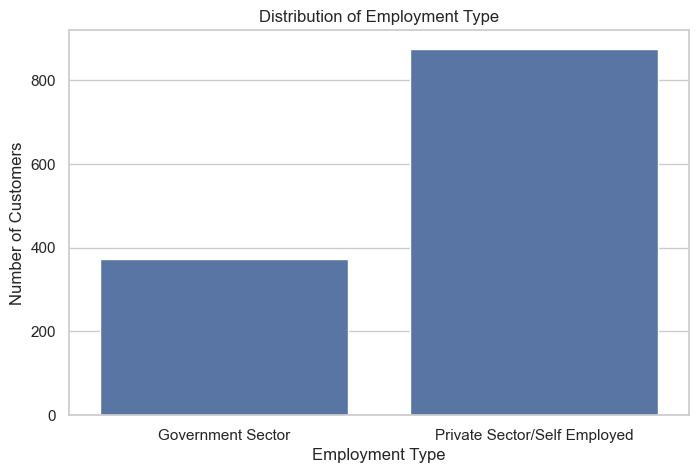

In [41]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Employment Type")

plt.title("Distribution of Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Number of Customers")

plt.show()

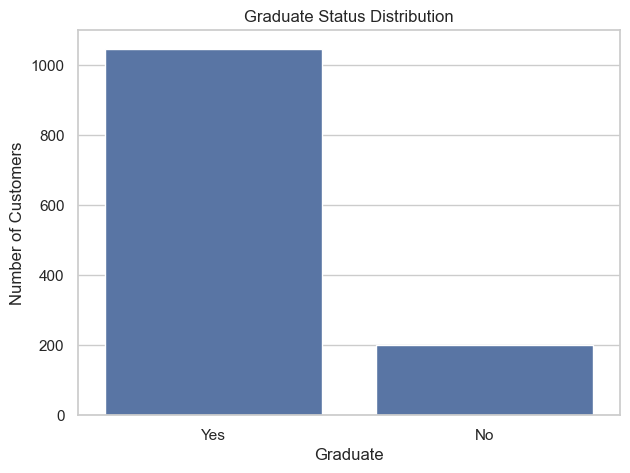

In [42]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="GraduateOrNot")

plt.title("Graduate Status Distribution")
plt.xlabel("Graduate")
plt.ylabel("Number of Customers")

plt.show()

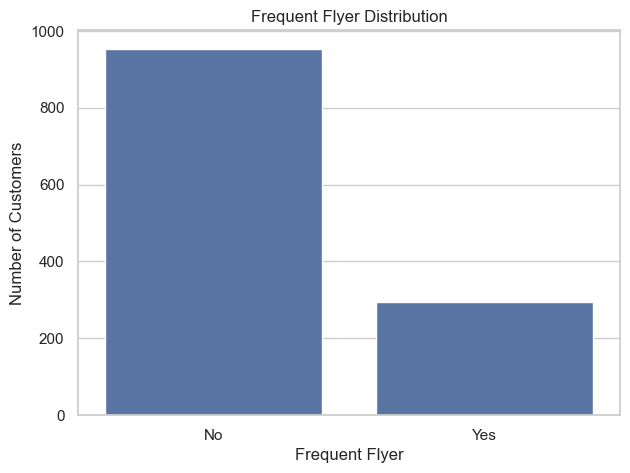

In [43]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="FrequentFlyer")

plt.title("Frequent Flyer Distribution")
plt.xlabel("Frequent Flyer")
plt.ylabel("Number of Customers")

plt.show()

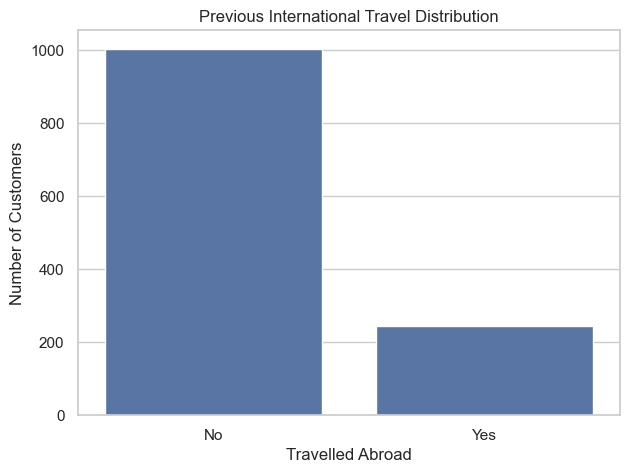

In [44]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="EverTravelledAbroad")

plt.title("Previous International Travel Distribution")
plt.xlabel("Travelled Abroad")
plt.ylabel("Number of Customers")

plt.show()

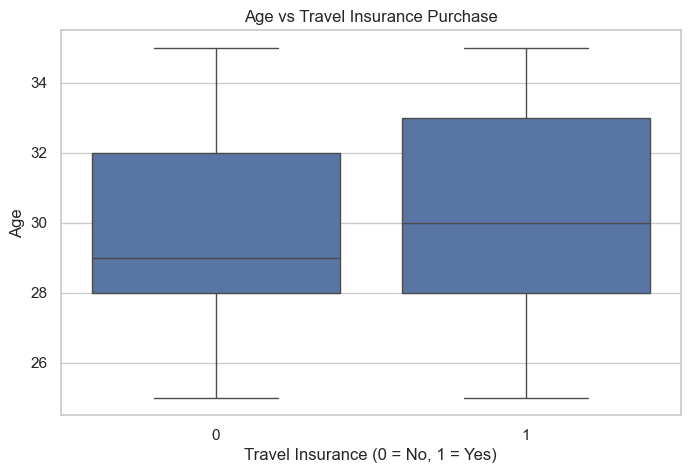

In [45]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="TravelInsurance",
    y="Age"
)

plt.title("Age vs Travel Insurance Purchase")
plt.xlabel("Travel Insurance (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.show()

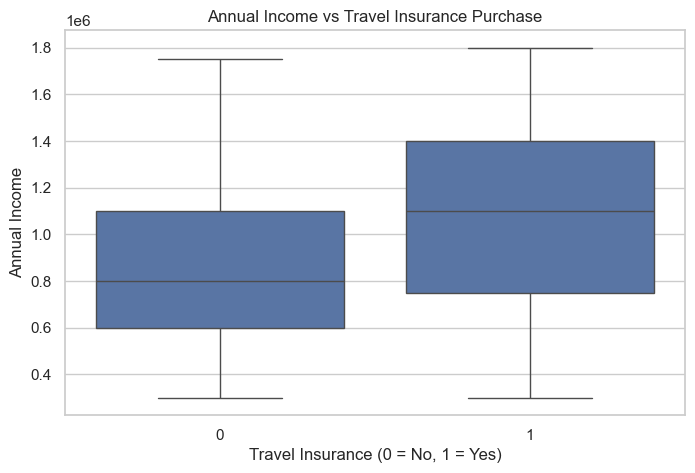

In [47]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="TravelInsurance",
    y="AnnualIncome"
)

plt.title("Annual Income vs Travel Insurance Purchase")
plt.xlabel("Travel Insurance (0 = No, 1 = Yes)")
plt.ylabel("Annual Income")

plt.show()

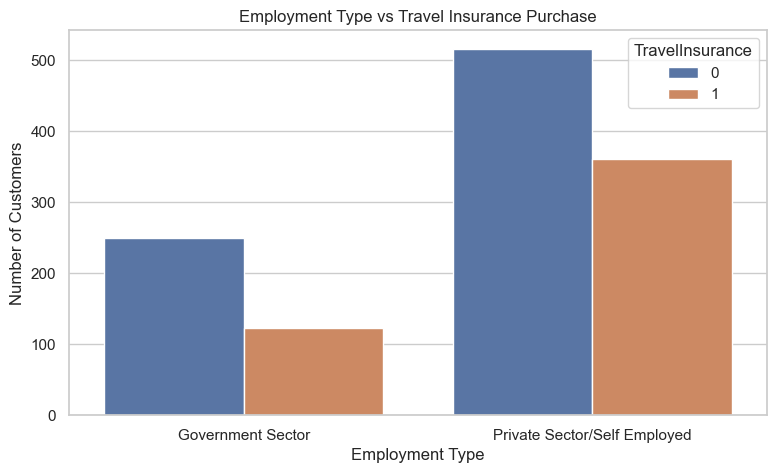

In [49]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Employment Type",
    hue="TravelInsurance"
)

plt.title("Employment Type vs Travel Insurance Purchase")
plt.xlabel("Employment Type")
plt.ylabel("Number of Customers")

plt.show()

In [50]:
df.groupby("Employment Type")["TravelInsurance"].mean() * 100

Employment Type
Government Sector               32.975871
Private Sector/Self Employed    41.095890
Name: TravelInsurance, dtype: float64

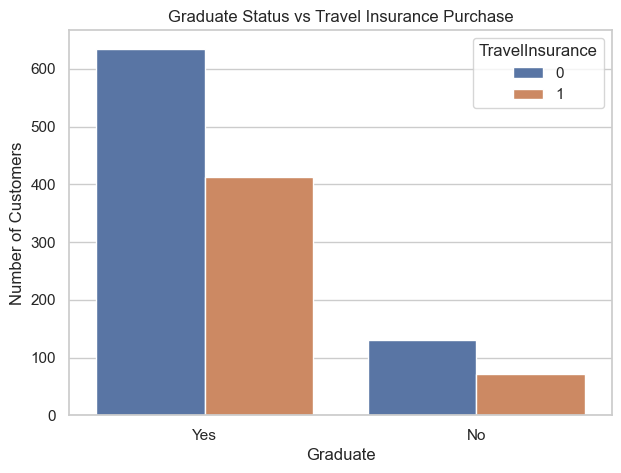

In [51]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="GraduateOrNot",
    hue="TravelInsurance"
)

plt.title("Graduate Status vs Travel Insurance Purchase")
plt.xlabel("Graduate")
plt.ylabel("Number of Customers")

plt.show()

In [52]:
df.groupby("GraduateOrNot")["TravelInsurance"].mean() * 100

GraduateOrNot
No     35.148515
Yes    39.350525
Name: TravelInsurance, dtype: float64

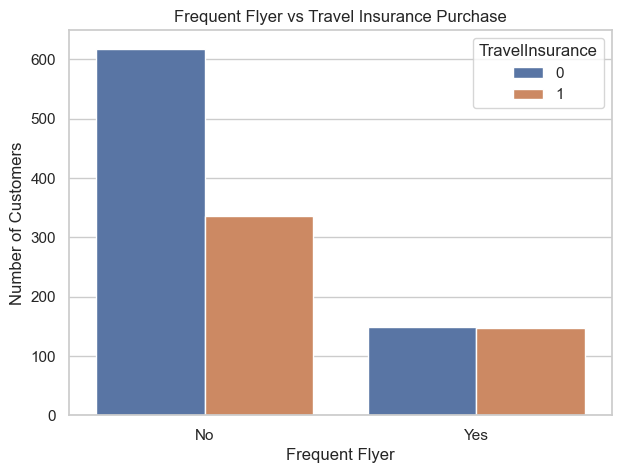

In [53]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="FrequentFlyer",
    hue="TravelInsurance"
)

plt.title("Frequent Flyer vs Travel Insurance Purchase")
plt.xlabel("Frequent Flyer")
plt.ylabel("Number of Customers")

plt.show()

In [54]:
df.groupby("FrequentFlyer")["TravelInsurance"].mean() * 100

FrequentFlyer
No     35.220126
Yes    49.830508
Name: TravelInsurance, dtype: float64

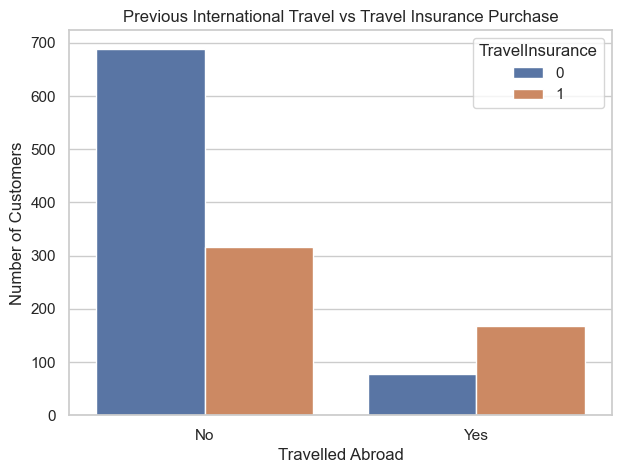

In [55]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="EverTravelledAbroad",
    hue="TravelInsurance"
)

plt.title("Previous International Travel vs Travel Insurance Purchase")
plt.xlabel("Travelled Abroad")
plt.ylabel("Number of Customers")

plt.show()

In [56]:
df.groupby("EverTravelledAbroad")["TravelInsurance"].mean() * 100

EverTravelledAbroad
No     31.442786
Yes    68.442623
Name: TravelInsurance, dtype: float64

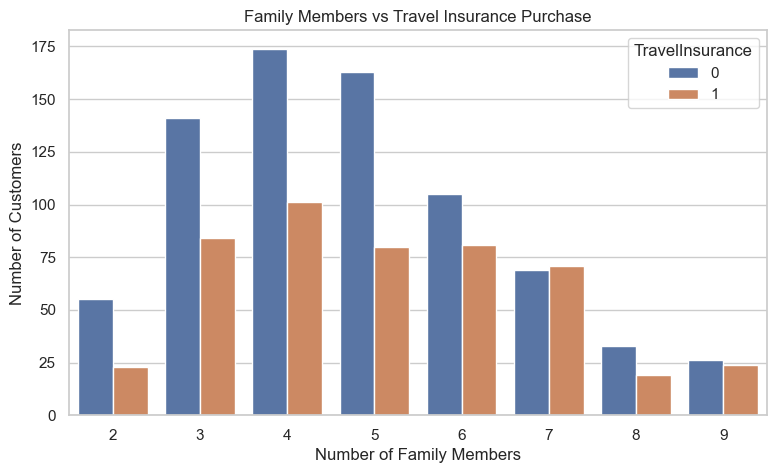

In [57]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="FamilyMembers",
    hue="TravelInsurance"
)

plt.title("Family Members vs Travel Insurance Purchase")
plt.xlabel("Number of Family Members")
plt.ylabel("Number of Customers")

plt.show()

In [58]:
df.groupby("FamilyMembers")["TravelInsurance"].mean() * 100

FamilyMembers
2    29.487179
3    37.333333
4    36.727273
5    32.921811
6    43.548387
7    50.714286
8    36.538462
9    48.000000
Name: TravelInsurance, dtype: float64

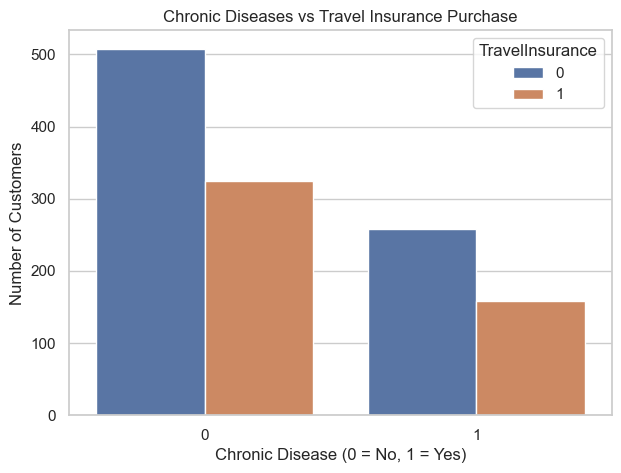

In [59]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="ChronicDiseases",
    hue="TravelInsurance"
)

plt.title("Chronic Diseases vs Travel Insurance Purchase")
plt.xlabel("Chronic Disease (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

In [61]:
df.groupby("ChronicDiseases")["TravelInsurance"].mean() * 100

ChronicDiseases
0    39.015606
1    37.980769
Name: TravelInsurance, dtype: float64

In [62]:
purchase_rates = {
    "Employment Type": df.groupby("Employment Type")["TravelInsurance"].mean() * 100,
    "GraduateOrNot": df.groupby("GraduateOrNot")["TravelInsurance"].mean() * 100,
    "FrequentFlyer": df.groupby("FrequentFlyer")["TravelInsurance"].mean() * 100,
    "EverTravelledAbroad": df.groupby("EverTravelledAbroad")["TravelInsurance"].mean() * 100,
    "ChronicDiseases": df.groupby("ChronicDiseases")["TravelInsurance"].mean() * 100,
    "FamilyMembers": df.groupby("FamilyMembers")["TravelInsurance"].mean() * 100
}

for feature, rates in purchase_rates.items():
    print(f"\n{feature}")
    print(rates.round(2))


Employment Type
Employment Type
Government Sector               32.98
Private Sector/Self Employed    41.10
Name: TravelInsurance, dtype: float64

GraduateOrNot
GraduateOrNot
No     35.15
Yes    39.35
Name: TravelInsurance, dtype: float64

FrequentFlyer
FrequentFlyer
No     35.22
Yes    49.83
Name: TravelInsurance, dtype: float64

EverTravelledAbroad
EverTravelledAbroad
No     31.44
Yes    68.44
Name: TravelInsurance, dtype: float64

ChronicDiseases
ChronicDiseases
0    39.02
1    37.98
Name: TravelInsurance, dtype: float64

FamilyMembers
FamilyMembers
2    29.49
3    37.33
4    36.73
5    32.92
6    43.55
7    50.71
8    36.54
9    48.00
Name: TravelInsurance, dtype: float64


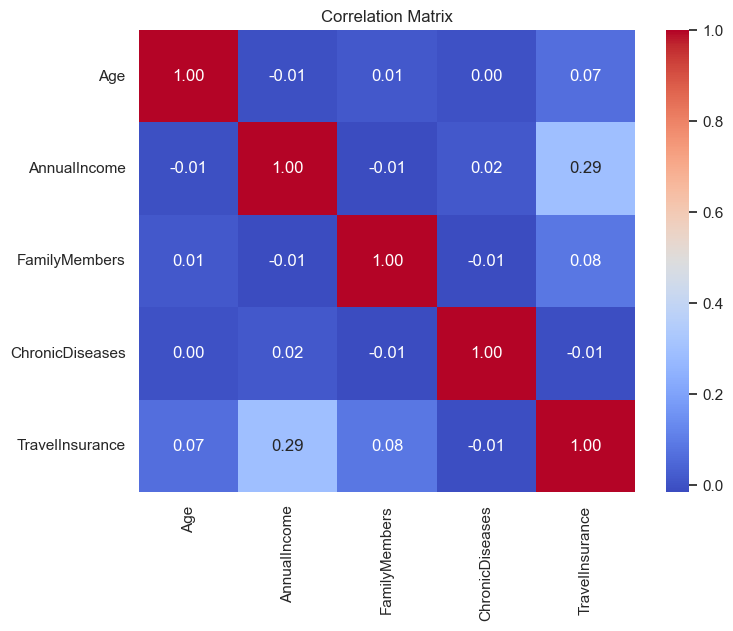

In [63]:
plt.figure(figsize=(8, 6))

correlation = df.select_dtypes(include="number").corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [64]:
df["IncomePerFamilyMember"] = (
    df["AnnualIncome"] / df["FamilyMembers"]
)

df[["AnnualIncome", "FamilyMembers", "IncomePerFamilyMember"]].head()

,AnnualIncome,FamilyMembers,IncomePerFamilyMember
0,400000,6,66666.666667
1,1250000,7,178571.428571
2,500000,4,125000.000000
3,700000,3,233333.333333
4,700000,8,87500.000000


In [65]:
df["IncomePerFamilyMember"].describe()

count      1249.000000
mean     220580.893286
std      128751.999186
min       33333.333333
25%      128571.428571
50%      200000.000000
75%      275000.000000
max      875000.000000
Name: IncomePerFamilyMember, dtype: float64

In [66]:
(df["FamilyMembers"] == 0).sum()

np.int64(0)

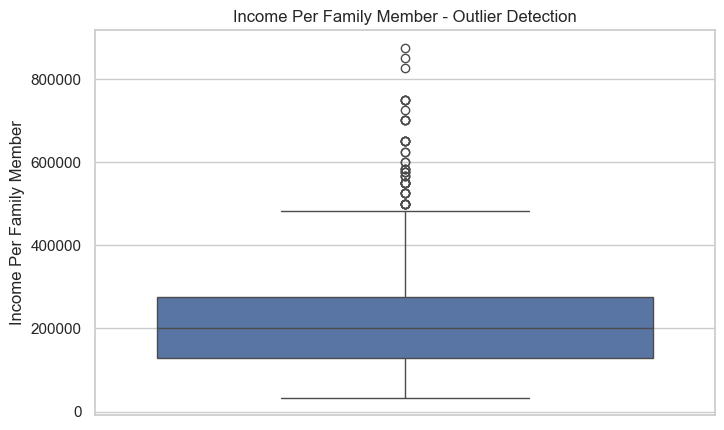

In [67]:
plt.figure(figsize=(8, 5))

sns.boxplot(y=df["IncomePerFamilyMember"])

plt.title("Income Per Family Member - Outlier Detection")
plt.ylabel("Income Per Family Member")

plt.show()

In [68]:
Q1 = df["IncomePerFamilyMember"].quantile(0.25)
Q3 = df["IncomePerFamilyMember"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 128571.42857142857
Q3: 275000.0
IQR: 146428.57142857142
Lower Bound: -91071.42857142857
Upper Bound: 494642.85714285716


In [69]:
outliers = df[
    (df["IncomePerFamilyMember"] < lower_bound) |
    (df["IncomePerFamilyMember"] > upper_bound)
]

print("Number of potential outliers:", len(outliers))

Number of potential outliers: 50


In [70]:
outliers[
    [
        "AnnualIncome",
        "FamilyMembers",
        "IncomePerFamilyMember"
    ]
].sort_values(
    "IncomePerFamilyMember",
    ascending=False
).head(20)

,AnnualIncome,FamilyMembers,IncomePerFamilyMember
1366,1750000,2,875000.0
319,1700000,2,850000.0
618,1650000,2,825000.0
19,1500000,2,750000.0
1869,1500000,2,750000.0
42,1500000,2,750000.0
1129,1500000,2,750000.0
1721,1450000,2,725000.0
253,1400000,2,700000.0
1383,1400000,2,700000.0


In [71]:
X = df.drop("TravelInsurance", axis=1)
y = df["TravelInsurance"]

In [72]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1249, 9)
y shape: (1249,)


In [73]:
numeric_features = [
    "Age",
    "AnnualIncome",
    "FamilyMembers",
    "ChronicDiseases",
    "IncomePerFamilyMember"
]

categorical_features = [
    "Employment Type",
    "GraduateOrNot",
    "FrequentFlyer",
    "EverTravelledAbroad"
]

In [74]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [76]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (999, 9)
X_test : (250, 9)
y_train: (999,)
y_test : (250,)


In [77]:
print("Original:")
print(y.value_counts(normalize=True) * 100)

print("\nTraining:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting:")
print(y_test.value_counts(normalize=True) * 100)

Original:
TravelInsurance
0    61.329063
1    38.670937
Name: proportion, dtype: float64

Training:
TravelInsurance
0    61.361361
1    38.638639
Name: proportion, dtype: float64

Testing:
TravelInsurance
0    61.2
1    38.8
Name: proportion, dtype: float64


In [78]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(random_state=42))
    ]
)

In [79]:
logistic_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [80]:
y_pred_logistic = logistic_model.predict(X_test)

In [81]:
y_pred_logistic[:20]

array([0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0])

In [82]:
print("Actual:")
print(y_test.values[:20])

print("\nPredicted:")
print(y_pred_logistic[:20])

Actual:
[0 1 0 1 1 0 1 1 0 1 0 0 1 0 0 1 1 1 0 0]

Predicted:
[0 0 1 1 0 0 0 1 0 0 0 1 1 0 1 0 1 0 1 0]


In [83]:
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

In [84]:
y_prob_logistic[:10]

array([0.46224389, 0.15612812, 0.61594453, 0.69307247, 0.47986575,
       0.36311981, 0.34131784, 0.59880208, 0.26823443, 0.3163449 ])

In [85]:
print(
    "Training Accuracy:",
    logistic_model.score(X_train, y_train)
)

print(
    "Testing Accuracy:",
    logistic_model.score(X_test, y_test)
)

Training Accuracy: 0.7167167167167167
Testing Accuracy: 0.656


In [86]:
accuracy = accuracy_score(y_test, y_pred_logistic)

print("Accuracy:", round(accuracy, 4))

Accuracy: 0.656


In [87]:
precision = precision_score(y_test, y_pred_logistic)

print("Precision:", round(precision, 4))

Precision: 0.5902


In [88]:
recall = recall_score(y_test, y_pred_logistic)

print("Recall:", round(recall, 4))

Recall: 0.3711


In [89]:
f1 = f1_score(y_test, y_pred_logistic)

print("F1 Score:", round(f1, 4))

F1 Score: 0.4557


In [90]:
roc_auc = roc_auc_score(
    y_test,
    y_prob_logistic
)

print("ROC-AUC:", round(roc_auc, 4))

ROC-AUC: 0.6458


In [91]:
logistic_results = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc
}

print("Logistic Regression Results")
print("-" * 35)

for metric, value in logistic_results.items():
    print(f"{metric}: {value:.4f}")

Logistic Regression Results
-----------------------------------
Accuracy: 0.6560
Precision: 0.5902
Recall: 0.3711
F1 Score: 0.4557
ROC-AUC: 0.6458


In [92]:
cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

print(cm)

[[128  25]
 [ 61  36]]


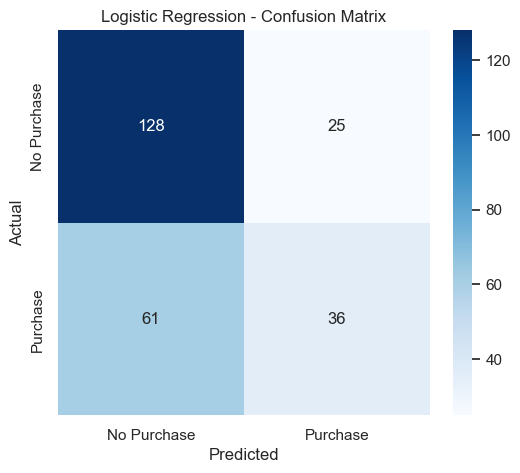

In [93]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [94]:
tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42,
                max_depth=5
            )
        )
    ]
)

In [95]:
tree_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [96]:
y_pred_tree = tree_model.predict(X_test)

In [97]:
print("Actual:")
print(y_test.values[:20])

print("\nPredicted:")
print(y_pred_tree[:20])

Actual:
[0 1 0 1 1 0 1 1 0 1 0 0 1 0 0 1 1 1 0 0]

Predicted:
[0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 0 1 0 0 0]


In [98]:
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]

In [99]:
y_prob_tree[:10]

array([0.25454545, 0.26303318, 0.5       , 0.84375   , 0.26303318,
       0.26303318, 0.26303318, 0.84375   , 0.25454545, 0.4       ])

In [100]:
print(
    "Training Accuracy:",
    tree_model.score(X_train, y_train)
)

print(
    "Testing Accuracy:",
    tree_model.score(X_test, y_test)
)

Training Accuracy: 0.7867867867867868
Testing Accuracy: 0.744


In [101]:
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)
tree_roc_auc = roc_auc_score(y_test, y_prob_tree)

print("Decision Tree Results")
print("-" * 35)

print("Accuracy :", round(tree_accuracy, 4))
print("Precision:", round(tree_precision, 4))
print("Recall   :", round(tree_recall, 4))
print("F1 Score :", round(tree_f1, 4))
print("ROC-AUC  :", round(tree_roc_auc, 4))

Decision Tree Results
-----------------------------------
Accuracy : 0.744
Precision: 0.8667
Recall   : 0.4021
F1 Score : 0.5493
ROC-AUC  : 0.7288


In [102]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

print(cm_tree)

[[147   6]
 [ 58  39]]


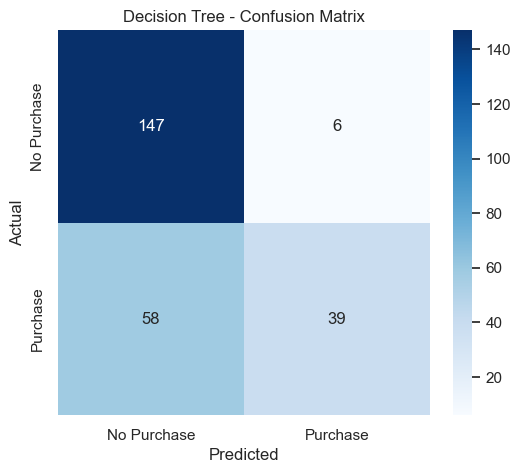

In [103]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [104]:
forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

In [105]:
forest_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [106]:
y_pred_forest = forest_model.predict(X_test)

In [107]:
print("Actual:")
print(y_test.values[:20])

print("\nPredicted:")
print(y_pred_forest[:20])

Actual:
[0 1 0 1 1 0 1 1 0 1 0 0 1 0 0 1 1 1 0 0]

Predicted:
[0 0 1 1 0 1 0 1 1 0 0 0 1 0 1 0 1 0 0 1]


In [108]:
y_prob_forest = forest_model.predict_proba(X_test)[:, 1]

In [109]:
y_prob_forest[:10]

array([0.09083333, 0.30875   , 0.58833333, 0.97666667, 0.14175   ,
       0.86383333, 0.25941667, 0.65658333, 0.7265    , 0.2285    ])

In [112]:
print(
    "Training Accuracy:",
    forest_model.score(X_train, y_train)
)

print(
    "Testing Accuracy:",
    forest_model.score(X_test, y_test)
)

Training Accuracy: 0.914914914914915
Testing Accuracy: 0.632


In [113]:
forest_accuracy = accuracy_score(y_test, y_pred_forest)
forest_precision = precision_score(y_test, y_pred_forest)
forest_recall = recall_score(y_test, y_pred_forest)
forest_f1 = f1_score(y_test, y_pred_forest)
forest_roc_auc = roc_auc_score(y_test, y_prob_forest)

print("Random Forest Results")
print("-" * 35)

print("Accuracy :", round(forest_accuracy, 4))
print("Precision:", round(forest_precision, 4))
print("Recall   :", round(forest_recall, 4))
print("F1 Score :", round(forest_f1, 4))
print("ROC-AUC  :", round(forest_roc_auc, 4))

Random Forest Results
-----------------------------------
Accuracy : 0.632
Precision: 0.5333
Recall   : 0.4124
F1 Score : 0.4651
ROC-AUC  : 0.5682


In [114]:
cm_forest = confusion_matrix(
    y_test,
    y_pred_forest
)

print(cm_forest)

[[118  35]
 [ 57  40]]


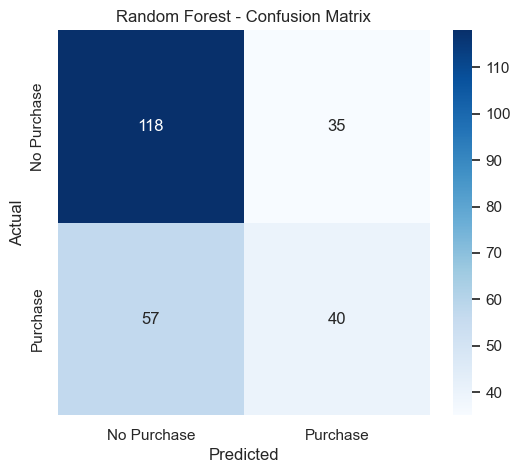

In [115]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_forest,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [116]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    
    "Accuracy": [
        accuracy,
        tree_accuracy,
        forest_accuracy
    ],
    
    "Precision": [
        precision,
        tree_precision,
        forest_precision
    ],
    
    "Recall": [
        recall,
        tree_recall,
        forest_recall
    ],
    
    "F1 Score": [
        f1,
        tree_f1,
        forest_f1
    ],
    
    "ROC-AUC": [
        roc_auc,
        tree_roc_auc,
        forest_roc_auc
    ]
})

comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.656,0.5902,0.3711,0.4557,0.6458
1,Decision Tree,0.744,0.8667,0.4021,0.5493,0.7288
2,Random Forest,0.632,0.5333,0.4124,0.4651,0.5682


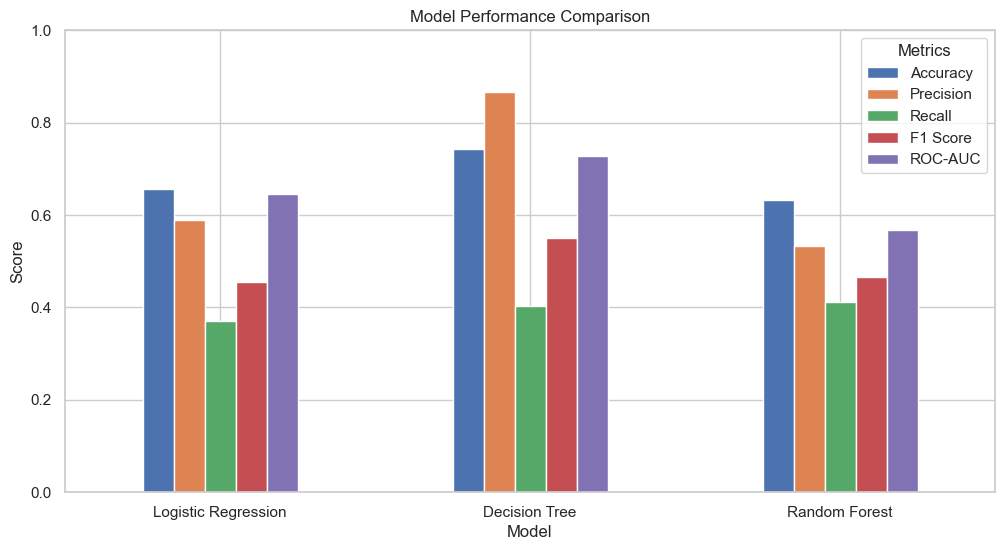

In [117]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

comparison_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.ylim(0, 1)

plt.show()

In [118]:
forest_preprocessor = forest_model.named_steps["preprocessor"]

forest_classifier = forest_model.named_steps["model"]

In [119]:
feature_names = forest_preprocessor.get_feature_names_out()

print(feature_names)

['num__Age' 'num__AnnualIncome' 'num__FamilyMembers'
 'num__ChronicDiseases' 'num__IncomePerFamilyMember'
 'cat__Employment Type_Private Sector/Self Employed'
 'cat__GraduateOrNot_Yes' 'cat__FrequentFlyer_Yes'
 'cat__EverTravelledAbroad_Yes']


In [120]:
importance = forest_classifier.feature_importances_

print(importance)

[0.17255816 0.28175537 0.11973795 0.06301018 0.21402155 0.03030142
 0.0222842  0.03953106 0.05680011]


In [121]:
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

In [122]:
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

In [123]:
feature_importance_df

,Feature,Importance
1,num__AnnualIncome,0.281755
4,num__IncomePerFamilyMember,0.214022
0,num__Age,0.172558
2,num__FamilyMembers,0.119738
3,num__ChronicDiseases,0.063010
8,cat__EverTravelledAbroad_Yes,0.056800
7,cat__FrequentFlyer_Yes,0.039531
5,cat__Employment Type_Private Sector/Self Employed,0.030301
6,cat__GraduateOrNot_Yes,0.022284


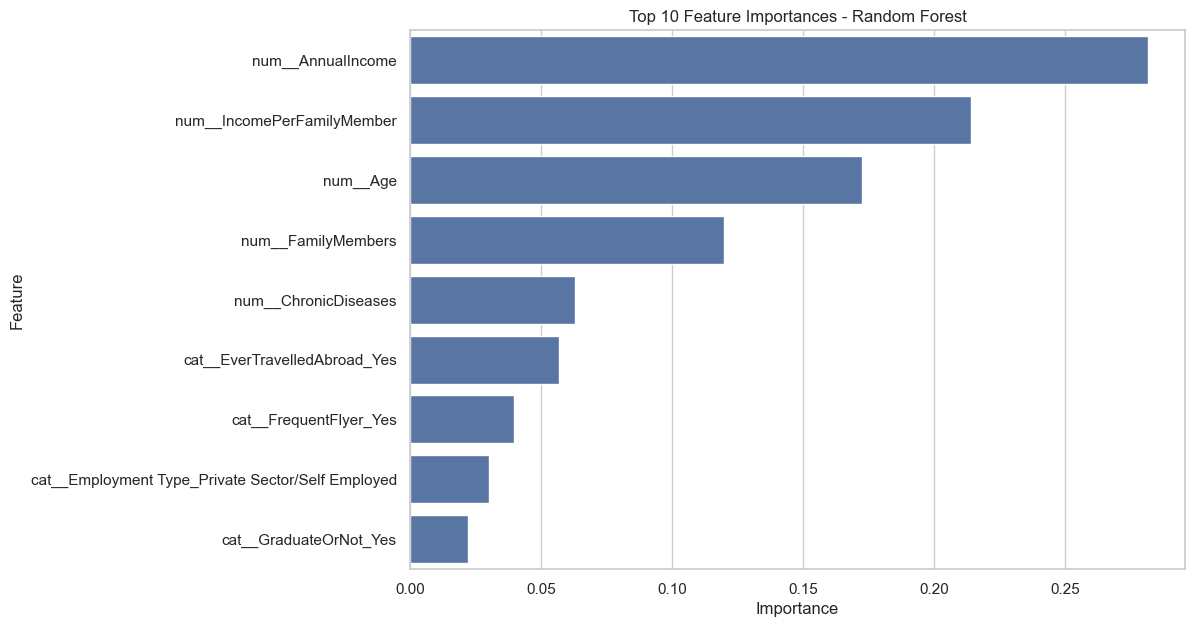

In [124]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

**SAMPLE CUSTOMER PREDICTIONS**

In [125]:
sample_customer = pd.DataFrame({
    "Age": [30],
    "Employment Type": ["Private Sector/Self Employed"],
    "GraduateOrNot": ["Yes"],
    "AnnualIncome": [1000000],
    "FamilyMembers": [4],
    "ChronicDiseases": [0],
    "FrequentFlyer": ["Yes"],
    "EverTravelledAbroad": ["Yes"]
})

In [126]:
sample_customer["IncomePerFamilyMember"] = (
    sample_customer["AnnualIncome"] /
    sample_customer["FamilyMembers"]
)

In [127]:
sample_customer

,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,IncomePerFamilyMember
0,30,Private Sector/Self Employed,Yes,1000000,4,0,Yes,Yes,250000.0


In [128]:
prediction = forest_model.predict(sample_customer)

print("Prediction:", prediction[0])

Prediction: 0


In [129]:
probability = forest_model.predict_proba(
    sample_customer
)[0][1]

print(
    "Purchase Probability:",
    round(probability * 100, 2),
    "%"
)

Purchase Probability: 22.0 %


In [130]:
if prediction[0] == 1:
    print("Prediction: Customer is likely to purchase travel insurance.")
else:
    print("Prediction: Customer is unlikely to purchase travel insurance.")

print(
    "Estimated Purchase Probability:",
    round(probability * 100, 2),
    "%"
)

Prediction: Customer is unlikely to purchase travel insurance.
Estimated Purchase Probability: 22.0 %


In [131]:
comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.656,0.5902,0.3711,0.4557,0.6458
1,Decision Tree,0.744,0.8667,0.4021,0.5493,0.7288
2,Random Forest,0.632,0.5333,0.4124,0.4651,0.5682


In [132]:
feature_importance_df.round(4)

,Feature,Importance
1,num__AnnualIncome,0.2818
4,num__IncomePerFamilyMember,0.2140
0,num__Age,0.1726
2,num__FamilyMembers,0.1197
3,num__ChronicDiseases,0.0630
8,cat__EverTravelledAbroad_Yes,0.0568
7,cat__FrequentFlyer_Yes,0.0395
5,cat__Employment Type_Private Sector/Self Employed,0.0303
6,cat__GraduateOrNot_Yes,0.0223


In [133]:
df["TravelInsurance"].value_counts()

TravelInsurance
0    766
1    483
Name: count, dtype: int64

In [134]:
df["TravelInsurance"].value_counts(normalize=True).mul(100).round(2)

TravelInsurance
0    61.33
1    38.67
Name: proportion, dtype: float64

In [135]:
purchase_rates

{'Employment Type': Employment Type
 Government Sector               32.975871
 Private Sector/Self Employed    41.095890
 Name: TravelInsurance, dtype: float64,
 'GraduateOrNot': GraduateOrNot
 No     35.148515
 Yes    39.350525
 Name: TravelInsurance, dtype: float64,
 'FrequentFlyer': FrequentFlyer
 No     35.220126
 Yes    49.830508
 Name: TravelInsurance, dtype: float64,
 'EverTravelledAbroad': EverTravelledAbroad
 No     31.442786
 Yes    68.442623
 Name: TravelInsurance, dtype: float64,
 'ChronicDiseases': ChronicDiseases
 0    39.015606
 1    37.980769
 Name: TravelInsurance, dtype: float64,
 'FamilyMembers': FamilyMembers
 2    29.487179
 3    37.333333
 4    36.727273
 5    32.921811
 6    43.548387
 7    50.714286
 8    36.538462
 9    48.000000
 Name: TravelInsurance, dtype: float64}